# r/sandiego

#### Reddit group description:

### Topic Modeling

In [1]:
import pandas as pd
import re
import gensim
import pyLDAvis
import pyLDAvis.gensim_models
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /Users/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/admin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
# Load and examine data
df = pd.read_csv('Data/reddit/sandiego.csv')
print(f"Loaded {len(df)} comments")
print(f"Columns: {df.columns.tolist()}")
print(f"First few comments:")
for i in range(3):
    print(f"{i+1}: {df.iloc[i, 0][:100]}...")

Loaded 16736 comments
Columns: ['0']
First few comments:
1: Missed connection SAN to SJD may 30 Alaska...
2: This clearly marked bright yellow no trespassing rope definitely doesn’t mean you because you are a ...
3: I work in retail. People will ignore signs unless it's at eye level at first glance. We would close ...


In [3]:
# Clean and prepare text
def clean_text(text):
    if not isinstance(text, str) or text in ['[deleted]', '[removed]', '']:
        return ""
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove punctuation, numbers, etc.
    text = re.sub(r"[^A-Za-z\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

# Apply cleaning
comments = df.iloc[:, 0].apply(clean_text)
comments = comments[comments.str.len() > 10]  # Remove very short comments
print(f"After cleaning: {len(comments)} comments")

# Tokenize and remove stopwords
swords = stopwords.words('english')

# Remove punctuation from stopwords to match your cleaned text
swords_clean = []
for word in swords:
    # Apply same cleaning as clean_text function
    clean_word = re.sub(r"[^A-Za-z\s]", "", word)
    if clean_word and len(clean_word) > 0:
        swords_clean.append(clean_word.lower())

# Remove duplicates and empty strings
swords_clean = list(set([word for word in swords_clean if word]))
swords_clean = sorted(swords_clean)

print(f"Original stopwords: {len(swords)}")
# print(swords)
print(f"Cleaned stopwords: {len(swords_clean)}")
# print(swords_clean)

# Add specific stopwords
reddit_stopwords = ['reddit', 'edit', 'update', 'deleted', 'removed', 'comment', 'post', 'thread']
additional_stopwords = ['lets', 'thats', 'people', 'even', 'time', 'way', 'thats', 'youre', 'much', 
                        'would', 'could', 'get', 'one', 'also', 'really', 'think', 'know', 'like']

swords_clean.extend(reddit_stopwords + additional_stopwords)

print(f"Extended stopwords: {len(swords_clean)}")
# print(swords_clean)

# Tokenize
wordlists = []
for comment in comments:
    words = [word for word in word_tokenize(comment.lower()) 
            if word not in swords_clean 
            and len(word) > 0
            and word.isalpha()]
    
    wordlists.append(words)

print(f"Prepared {len(wordlists)} comments for modeling")

After cleaning: 15832 comments
Original stopwords: 198
Cleaned stopwords: 196
Extended stopwords: 222
Prepared 15832 comments for modeling


In [4]:
# Analyze word frequencies
all_words = [word for wordlist in wordlists for word in wordlist]
word_freq = Counter(all_words)

print("Top 20 most common words:")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")

Top 20 most common words:
go: 1048
good: 863
san: 823
going: 820
city: 727
make: 720
diego: 719
want: 710
need: 704
us: 671
right: 669
ice: 660
see: 655
years: 653
work: 642
take: 571
still: 555
got: 554
back: 551
lot: 545


In [5]:
# Run topic model
def run_topic_model(wordlists, num_topics=4, alpha=0.7, eta=0.5):
    dictionary = gensim.corpora.Dictionary(wordlists)
    dictionary.filter_extremes(no_below=2, no_above=0.5)
    corpus = [dictionary.doc2bow(wl) for wl in wordlists]
    
    model = gensim.models.LdaMulticore(
        corpus, 
        id2word=dictionary, 
        num_topics=num_topics,
        alpha=alpha,
        eta=eta,
        random_state=1
    )
    
    return model, corpus, dictionary

# Run the model
model, corpus, dictionary = run_topic_model(wordlists, num_topics=4)

# Display topics
print("Topics found:")
print("=" * 50)

for idx, topic in model.show_topics(formatted=False, num_words=10):
    print(f"\nTopic {idx + 1}:")
    words = [word for word, prob in topic]
    print(f"{', '.join(words)}")

# Visualize topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(model, corpus, dictionary)
vis

Topics found:

Topic 1:
go, san, diego, going, good, got, see, right, work, want

Topic 2:
go, good, need, going, make, right, want, years, san, lot

Topic 3:
going, right, make, go, us, good, want, take, city, ice

Topic 4:
ice, see, good, want, san, go, us, diego, need, going


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.002343 -0.002041       1        1  26.487157
2     -0.005436  0.000506       2        1  24.531031
1      0.000895 -0.003195       3        1  24.509700
3      0.002197  0.004729       4        1  24.472113, topic_info=         Term        Freq       Total Category  logprob  loglift
1004      ice  633.000000  633.000000  Default  30.0000  30.0000
122        go  900.000000  900.000000  Default  29.0000  29.0000
1545      due  276.000000  276.000000  Default  28.0000  28.0000
566   process  326.000000  326.000000  Default  27.0000  27.0000
352         k  240.000000  240.000000  Default  26.0000  26.0000
...       ...         ...         ...      ...      ...      ...
397      make  123.330600  629.880249   Topic4  -6.0550  -0.2230
256      back  113.551937  515.022734   Topic4  -6.1376  -0.1043
672       day  101.965584  442.795782   Topic4  -6.2452  -0.0608
473   someone   99.515032  399.020642   Topic4  -6.2695   0.0189
1254    every   99.538219  425.411632   Topic4  -6.2693  -0.0449

[366 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
7289      1  0.208552  accusation
7289      2  0.417105  accusation
7289      3  0.104276  accusation
7289      4  0.208552  accusation
2901      1  0.238094    accusing
...     ...       ...         ...
1498      4  0.243871       years
67        1  0.214210         yes
67        2  0.240516         yes
67        3  0.296887         yes
67        4  0.248032         yes

[1028 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 3, 2, 4])

### Sentiment Analysis

In [6]:
# Sentiment Analysis for Reddit Comments
from textblob import TextBlob
import pandas as pd

# Apply sentiment analysis to your cleaned comments
print("Analyzing sentiment...")
sentiment_scores = [TextBlob(comment).sentiment.polarity for comment in comments]

# Create dataframe with comments and polarity scores
df_sentiment = pd.DataFrame({
    'comment': comments,
    'polarity': sentiment_scores
})

print(f"Analyzed {len(df_sentiment)} comments")
print(f"Sentiment analysis complete!")

# Display basic statistics
print(f"\nSentiment Statistics:")
print(f"Mean polarity: {df_sentiment['polarity'].mean():.3f}")
print(f"Median polarity: {df_sentiment['polarity'].median():.3f}")
print(f"Min polarity: {df_sentiment['polarity'].min():.3f}")
print(f"Max polarity: {df_sentiment['polarity'].max():.3f}")

# Categorize sentiments
df_sentiment['sentiment_category'] = df_sentiment['polarity'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

print(f"\nSentiment Distribution:")
print(df_sentiment['sentiment_category'].value_counts())

# Show examples
print(f"\nMost Positive Comments:")
print(df_sentiment.nlargest(3, 'polarity')[['comment', 'polarity']])

print(f"\nMost Negative Comments:")
print(df_sentiment.nsmallest(3, 'polarity')[['comment', 'polarity']])

Analyzing sentiment...
Analyzed 15832 comments
Sentiment analysis complete!

Sentiment Statistics:
Mean polarity: 0.064
Median polarity: 0.000
Min polarity: -1.000
Max polarity: 1.000

Sentiment Distribution:
sentiment_category
Neutral     7846
Positive    5377
Negative    2609
Name: count, dtype: int64

Most Positive Comments:
                                               comment  polarity
24   Meanwhile Ive been standing in line to pick up...       1.0
246                                  Best baked potato       1.0
254  Steak houses are always the best What part of ...       1.0

Most Negative Comments:
                                                comment  polarity
151                                    This is so awful      -1.0
1340             San Antonio and Alabama have the worst      -1.0
1363  I was not going to call it out and thought to ...      -1.0


parking: 281 comments found
sleep: 58 comments found
bathroom: 29 comments found
water: 191 comments found
cook: 41 comments found
police: 231 comments found
noise: 51 comments found
solar: 27 comments found
job: 343 comments found


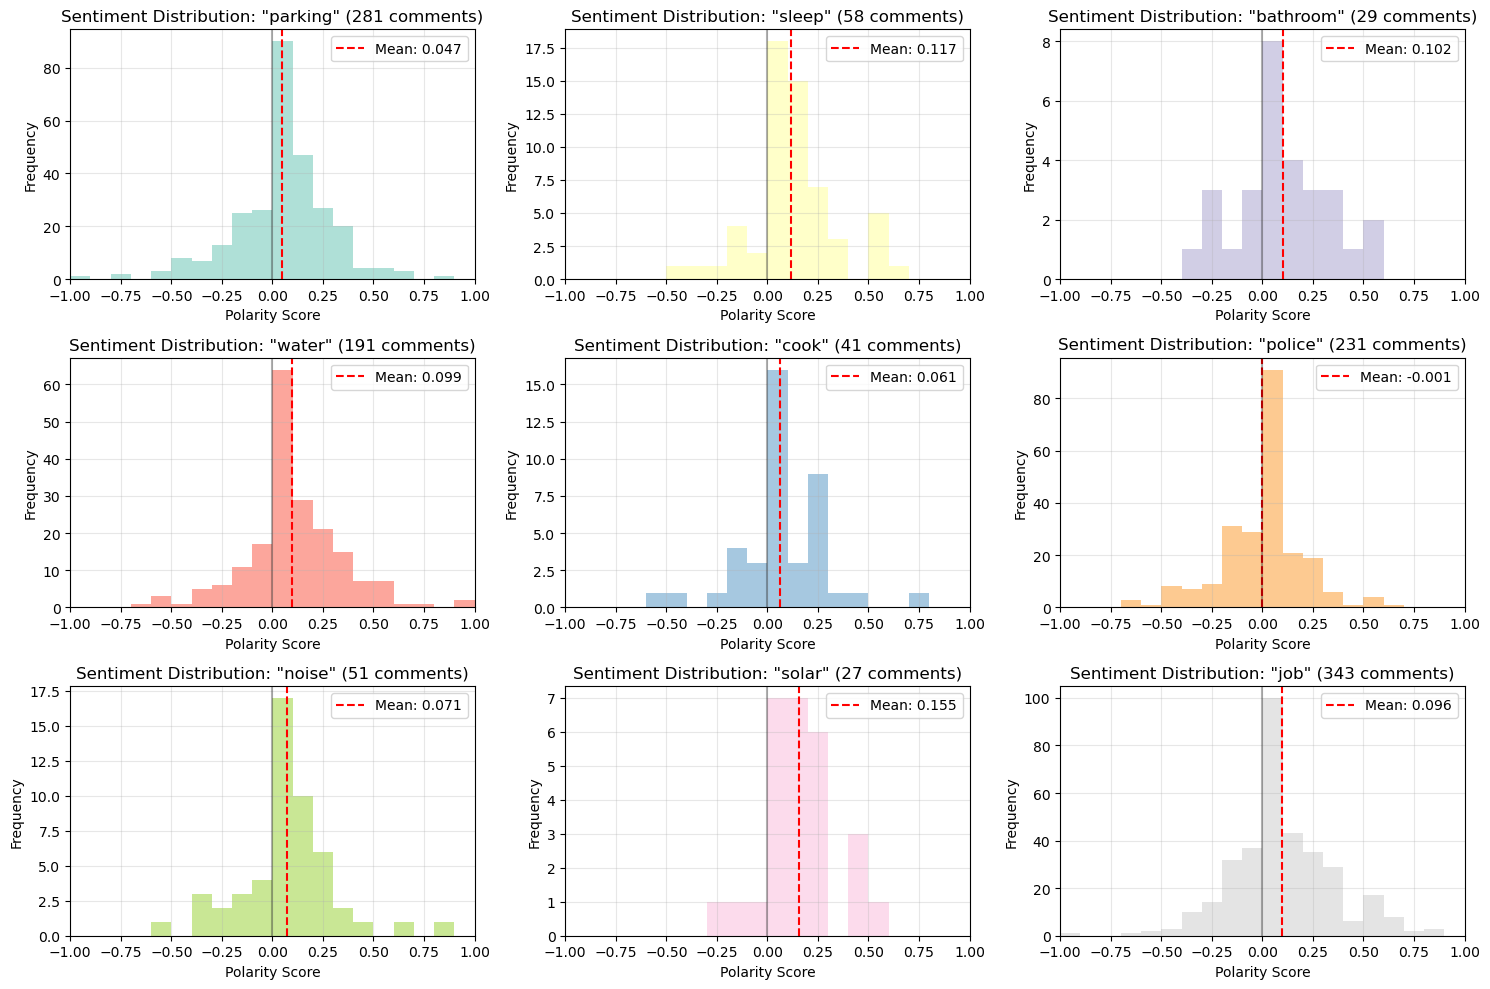

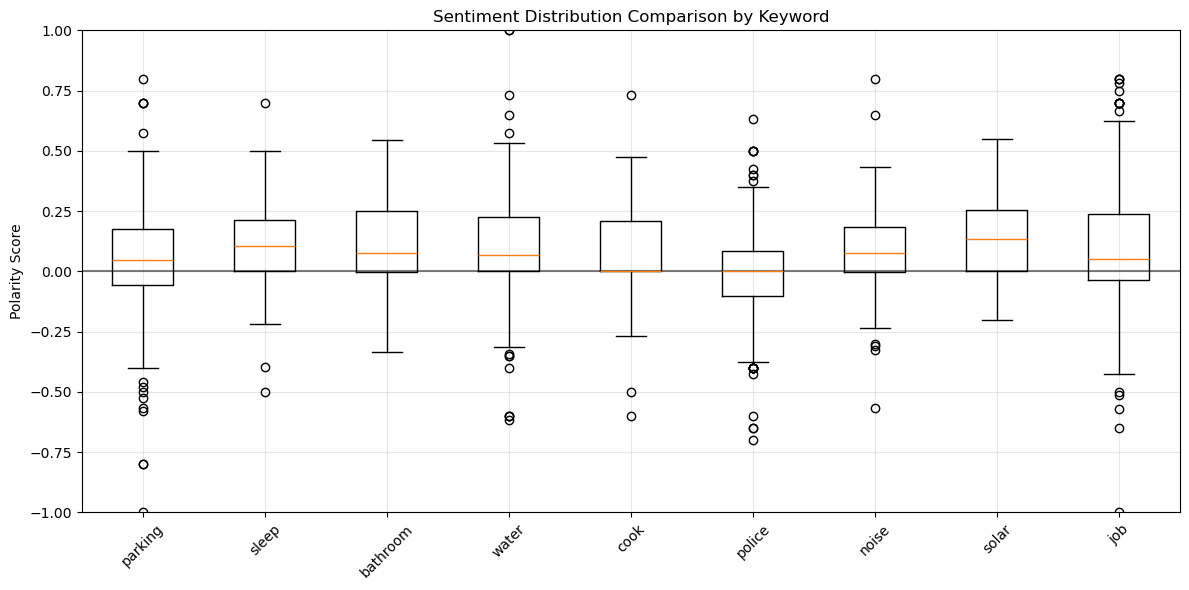

In [8]:
import matplotlib.pyplot as plt
import numpy as np


# Define keywords to analyze
keywords = ['parking', 'sleep', 'bathroom', 'water', 'cook', 'police', 'noise', 'solar', 'job']

# Function to find comments containing specific keywords
def get_sentiment_by_keyword(df_sentiment, keyword):
    mask = df_sentiment['comment'].str.contains(keyword, case=False, na=False)
    return df_sentiment[mask]['polarity']

# Collect sentiment data for each keyword
keyword_sentiments = {}
for keyword in keywords:
    sentiments = get_sentiment_by_keyword(df_sentiment, keyword)
    keyword_sentiments[keyword] = sentiments
    print(f"{keyword}: {len(sentiments)} comments found")

# Create subplot for each keyword
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
x_min, x_max = -1.0, 1.0  
bins = np.linspace(x_min, x_max, 21)  

for i, keyword in enumerate(keywords):
    sentiments = keyword_sentiments[keyword]
    
    if len(sentiments) > 0:
        # Create histogram with consistent bins and x-axis
        axes[i].hist(sentiments, bins=bins, alpha=0.7, color=plt.cm.Set3(i))
        axes[i].axvline(sentiments.mean(), color='red', linestyle='--', 
                       label=f'Mean: {sentiments.mean():.3f}')
        axes[i].set_title(f'Sentiment Distribution: "{keyword}" ({len(sentiments)} comments)')
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')
        axes[i].set_xlim(x_min, x_max)  # Consistent x-axis range
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Add vertical line at 0 for reference
        axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, f'No comments found\nfor "{keyword}"', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'Sentiment Distribution: "{keyword}"')
        axes[i].set_xlim(x_min, x_max)  # Keep same x-axis even for empty plots
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plot comparison with consistent y-axis
plt.figure(figsize=(12, 6))
sentiment_data = [keyword_sentiments[keyword] for keyword in keywords if len(keyword_sentiments[keyword]) > 0]
labels = [keyword for keyword in keywords if len(keyword_sentiments[keyword]) > 0]

if sentiment_data:
    plt.boxplot(sentiment_data, labels=labels)
    plt.title('Sentiment Distribution Comparison by Keyword')
    plt.ylabel('Polarity Score')
    plt.ylim(x_min, x_max)  
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No sentiment data found for any keywords")